# 🇹🇭 Thai Character Classification: Standalone Evaluation & Diagnostic Suite (`ver2`)
### Solution 3 (Pai + Pooh) — KMITL Deep Learning in Medical Imaging (Project 1)

This notebook provides a **dedicated, self-contained evaluation and benchmarking suite** for Thai Character Classification models.
You can evaluate any checkpoint (Solution 3 `ver2` ResNet-18, `ver2` Custom CNN, `ver1` Custom CNN, Solution 2 EfficientNet-B0, or custom weights) on any validation/test set with zero training required.

---
### 🎯 Evaluation Capabilities Included:
1. **Universal Dynamic Checkpoint Loader**: Auto-detects architecture (`AdaptedResNet18`, `CustomGlyphCNN`, `AdaptedEfficientNetB0`, `AdaptedMobileNetV3`), target resolution, stem adaptation, and parameter counts.
2. **Flexible Dataset & Split Selection**: Evaluate against single or multi-source datasets with zero-leakage deterministic 80/20 partitioning or explicit test sets.
3. **Comprehensive Metric Analytics**:
   - Top-1, Top-3, and Top-5 Accuracy
   - Macro-Averaged Precision, Recall, and F1-Score
   - Weighted-Averaged F1-Score & Balanced Accuracy
   - Inference Latency (ms/sample) and Throughput (samples/sec)
4. **Per-Class Breakdown & Performance Ranking**: Full 72-class classification report with Top-10 best vs Top-10 hardest characters.
5. **Advanced Confusion Matrix Visualizations**: Raw counts and Normalized (Recall) $72\times 72$ heatmaps with Matplotlib Thai font support.
6. **Linguistic Error Diagnostics & Confusion Gallery**: Top-15 most confused character pairs with typographical similarity analysis and visual misclassification gallery.
7. **Single-Sample Interactive Inference**: Step-by-step preprocessing breakdown and Top-5 confidence ranking with Thai linguistic metadata.
8. **Multi-Model Benchmark Leaderboard**: Automated comparative benchmarking across all available repository checkpoints.


## 1. Interactive Pipeline & Environment Setup
Configure your target checkpoint, validation dataset paths, and hardware accelerator below.

In [65]:
# ==============================================================================
# 🛠️ 1. GLOBAL PIPELINE CONFIGURATION & ENVIRONMENT SETUP
# ==============================================================================

import os
import sys
import io
import time
import math
import random
import importlib
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score

# ------------------------------------------------------------------------------
# 📂 1.1 PATH CONFIGURATION & SOURCE MODULE IMPORT
# ------------------------------------------------------------------------------
NOTEBOOK_DIR = Path.cwd()
VER2_DIR = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
SRC_DIR = VER2_DIR / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from font_utils import setup_thai_font
active_font = setup_thai_font()

import dataset as dataset_module
import models as models_module
import inference as inference_module
import transforms as transforms_module

importlib.reload(dataset_module)
importlib.reload(models_module)
importlib.reload(inference_module)
importlib.reload(transforms_module)

from dataset import tis620_to_char, letterbox_pad, build_split_dataframes, ThaiCharacterDataset, build_dataloaders
from models import CustomGlyphCNN, AdaptedResNet18, AdaptedMobileNetV3, AdaptedEfficientNetB0, build_model
from inference import THAI_CHAR_METADATA, ThaiCharacterInferenceEngine, UniversalModelLoader

# ------------------------------------------------------------------------------
# 🎯 1.2 INTERACTIVE CHECKPOINT SELECTION
# ------------------------------------------------------------------------------
# Discovered standard checkpoints in workspace:
CHECKPOINT_CATALOG = {
    'resnet18_ver2': VER2_DIR / 'checkpoints' / 'resnet18' / 'best_model.pt',
    'custom_cnn_ver2': VER2_DIR / 'checkpoints' / 'custom_cnn' / 'best_model.pt',
    'custom_cnn_ver1': VER2_DIR / '..' / 'ver1' / 'checkpoints' / 'custom_cnn' / 'best_model.pt'
}

# Choose active checkpoint key (or specify a custom Path):
# Options: 'resnet18_ver2', 'custom_cnn_ver2', 'custom_cnn_ver1', 'solution2_effnet', or Path(r"C:\custom\path.pt")
SELECTED_CHECKPOINT = 'resnet18_ver2'

# ------------------------------------------------------------------------------
# 📁 1.3 DATASET CONFIGURATION (Single or Multiple Sources)
# ------------------------------------------------------------------------------
DATASET_ROOT = (VER2_DIR / '..' / '..' / '..' / 'ThaiCharacterDataset').resolve()

# You can provide a list of dataset directories or a single directory:
CUSTOM_DATASET_DIR = [
    DATASET_ROOT / 'dataset-pai-cropped'
]
CUSTOM_VAL_DIR = None       # Set to specific validation directory Path if available, else auto 80/20 test split

def _resolve_paths(paths):
    if paths is None:
        return None
    if isinstance(paths, (str, Path)):
        p = Path(paths)
        return p if p.exists() else None
    resolved = [Path(p) for p in paths if Path(p).exists()]
    return resolved if resolved else None

DATASET_DIR = _resolve_paths(CUSTOM_DATASET_DIR)
if DATASET_DIR is None:
    # Fallback search
    fallback_candidates = [DATASET_ROOT / 'dataset-ajbank-cleaned', DATASET_ROOT / 'dataset-bam-100', DATASET_ROOT / 'round2-cleaned', DATASET_ROOT / 'round2']
    DATASET_DIR = next((p for p in fallback_candidates if p.exists()), None)

VAL_DIR = _resolve_paths(CUSTOM_VAL_DIR)

# ------------------------------------------------------------------------------
# ⚙️ 1.4 HARDWARE & EVALUATION PARAMETERS
# ------------------------------------------------------------------------------
SEED = 67
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

TRAIN_RATIO = 0.80             # 80/20 deterministic zero-leakage hash split
BATCH_SIZE = 128               # High-throughput evaluation batch size
CACHE_IN_RAM = True            # Ultra-fast RAM caching for test set
USE_FOCAL_CLEANER = False      # Connected Component Analysis peripheral cleaner
PAD_RATIO = 0.05               # Zero-padding letterbox margin

print("=" * 75)
print("⚙️  EVALUATION SUITE INITIALIZED")
print("=" * 75)
print(f"💻 Compute Device:     {device} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")
print(f"🇹🇭 Thai Font:          '{active_font}'")
if isinstance(DATASET_DIR, list):
    print(f"📁 Active Datasets:    {len(DATASET_DIR)} sources:")
    for d in DATASET_DIR:
        print(f"   • {d}")
else:
    print(f"📁 Active Dataset:     {DATASET_DIR}")
print("=" * 75)


⚙️  EVALUATION SUITE INITIALIZED
💻 Compute Device:     cuda (NVIDIA GeForce GTX 1650)
🇹🇭 Thai Font:          'Sarabun'
📁 Active Datasets:    1 sources:
   • C:\workspace\vscode\kmitl\3-1\dlmed\ThaiCharacterDataset\dataset-pai-cropped


## 2. Dynamic Checkpoint Loading & Architecture Introspection
The `UniversalModelLoader` automatically detects the architecture, input resolution, stem configuration, and metadata directly from the checkpoint.

In [66]:
# Resolve active checkpoint path
if isinstance(SELECTED_CHECKPOINT, str) and SELECTED_CHECKPOINT in CHECKPOINT_CATALOG:
    ckpt_path = CHECKPOINT_CATALOG[SELECTED_CHECKPOINT]
else:
    ckpt_path = Path(SELECTED_CHECKPOINT)

if not ckpt_path.exists():
    raise FileNotFoundError(f"Checkpoint not found at: {ckpt_path}")

# Load model with introspection
model, model_type, target_res, custom_class_map = UniversalModelLoader.inspect_and_load(
    checkpoint_path=ckpt_path,
    device=device,
    num_classes=72,
)

# Inspect checkpoint metadata dict
raw_ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
epoch_trained = raw_ckpt.get('epoch', 'N/A') if isinstance(raw_ckpt, dict) else 'N/A'
recorded_macro_f1 = raw_ckpt.get('val_f1_macro', raw_ckpt.get('macro_f1', raw_ckpt.get('val_f1', raw_ckpt.get('best_val_macro_f1', None)))) if isinstance(raw_ckpt, dict) else None
recorded_acc = raw_ckpt.get('val_acc', raw_ckpt.get('top1_acc', raw_ckpt.get('val_top1', None))) if isinstance(raw_ckpt, dict) else None

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
ckpt_size_mb = ckpt_path.stat().st_size / (1024 * 1024)

print("=" * 75)
print("🔍 CHECKPOINT INTROSPECTION REPORT")
print("=" * 75)
print(f"📦 Checkpoint File:      {ckpt_path.name} ({ckpt_size_mb:.2f} MB)")
print(f"📁 File Path:            {ckpt_path}")
print(f"🧠 Detected Architecture:{model_type} ({model.__class__.__name__})")
print(f"📐 Target Resolution:    {target_res}x{target_res}")
print(f"🔢 Output Classes:       {72 if custom_class_map is None else len(custom_class_map)}")
print(f"📊 Total Parameters:     {total_params:,} ({trainable_params:,} trainable)")
print(f"⏱️  Trained Epochs:       {epoch_trained}")
if recorded_macro_f1 is not None:
    print(f"⭐ Checkpoint Macro-F1:  {float(recorded_macro_f1)*100:.2f}%")
if recorded_acc is not None:
    print(f"🎯 Checkpoint Top-1 Acc: {float(recorded_acc)*100:.2f}%")
print("=" * 75)


🔍 CHECKPOINT INTROSPECTION REPORT
📦 Checkpoint File:      best_model.pt (129.76 MB)
📁 File Path:            c:\workspace\vscode\kmitl\3-1\dlmed\DL-in-Medical-Image-Project-1\Solution 3 (Pai + Pooh)\ver2\checkpoints\resnet18\best_model.pt
🧠 Detected Architecture:resnet18 (AdaptedResNet18)
📐 Target Resolution:    64x64
🔢 Output Classes:       72
📊 Total Parameters:     11,326,856 (11,326,856 trainable)
⏱️  Trained Epochs:       18
⭐ Checkpoint Macro-F1:  97.34%
🎯 Checkpoint Top-1 Acc: 97.14%


## 3. Test Dataset Loading & Partition Integrity Verification
We construct the test DataLoader using zero-leakage deterministic SHA-256 hash grouping, matching the identical train/test boundary used during training.

In [67]:
# Build DataLoaders matched to model target resolution
train_loader, test_loader, class_to_idx, train_df, test_df = build_dataloaders(
    dataset_dir=DATASET_DIR,
    val_dir=VAL_DIR,
    train_ratio=TRAIN_RATIO,
    batch_size=BATCH_SIZE,
    target_size=(target_res, target_res),
    num_workers=0,
    use_balanced_sampler=False,
    use_focal_cleaner=USE_FOCAL_CLEANER,
    use_pedestal_aug=False,
    cache_in_ram=CACHE_IN_RAM,
)

idx_to_class = {idx: cls_num for cls_num, idx in class_to_idx.items()}
num_classes = len(class_to_idx)

print(f"✅ Test Dataset Loaded: {len(test_df):,} samples across {test_df['class_idx'].nunique()} classes.")
print(f"   Class Support Range: Min={test_df['class_idx'].value_counts().min()} samples | Median={int(test_df['class_idx'].value_counts().median())} | Max={test_df['class_idx'].value_counts().max()}")

# Verify Zero Data Leakage
if 'group_key' in train_df.columns and 'group_key' in test_df.columns:
    overlap = set(train_df['group_key']).intersection(set(test_df['group_key']))
    if len(overlap) == 0:
        print("🛡️  Zero-Leakage Verified: 0 overlapping document page groups between train and test splits.")
    else:
        print(f"⚠️ Warning: {len(overlap)} overlapping group keys detected!")


[CACHE] Pre-caching 23,525 images into RAM (64x64 uint8)...
[CACHE] RAM caching complete: 23,525 images in 11.3s (91.9 MB RAM). Training throughput is now at maximum speed.
[CACHE] Pre-caching 5,699 images into RAM (64x64 uint8)...
[CACHE] RAM caching complete: 5,699 images in 2.8s (22.3 MB RAM). Training throughput is now at maximum speed.
✅ Test Dataset Loaded: 5,699 samples across 70 classes.
   Class Support Range: Min=64 samples | Median=82 | Max=96
🛡️  Zero-Leakage Verified: 0 overlapping document page groups between train and test splits.


## 4. Comprehensive Test Set Inference & Metrics Computation
Execute full validation inference across the test split to compute Top-1, Top-3, Top-5 accuracy, Macro & Weighted F1, precision, recall, and throughput.

In [68]:
model.eval()
all_preds, all_targets, all_probs = [], [], []
top3_correct, top5_correct, total = 0, 0, 0

t_start = time.time()
with torch.no_grad():
    for tensors, targets, _ in test_loader:
        tensors = tensors.to(device)
        targets_dev = targets.to(device)
        
        logits = model(tensors)
        probs = F.softmax(logits, dim=-1)
        preds = logits.argmax(dim=-1)
        
        all_preds.extend(preds.detach().cpu().numpy())
        all_targets.extend(targets.numpy())
        all_probs.extend(probs.detach().cpu().numpy())
        
        top3 = torch.topk(logits, k=min(3, logits.size(-1)), dim=-1).indices
        top3_correct += (top3 == targets_dev.unsqueeze(1)).any(dim=-1).sum().item()
        
        top5 = torch.topk(logits, k=min(5, logits.size(-1)), dim=-1).indices
        top5_correct += (top5 == targets_dev.unsqueeze(1)).any(dim=-1).sum().item()
        
        total += targets.size(0)

elapsed_time = time.time() - t_start
all_preds = np.array(all_preds)
all_targets = np.array(all_targets)
all_probs = np.array(all_probs)

# Compute Global Metrics
top1_acc = float((all_preds == all_targets).mean()) * 100.0
top3_acc = float(top3_correct / max(1, total)) * 100.0
top5_acc = float(top5_correct / max(1, total)) * 100.0
macro_f1 = float(f1_score(all_targets, all_preds, average='macro', zero_division=0)) * 100.0
weighted_f1 = float(f1_score(all_targets, all_preds, average='weighted', zero_division=0)) * 100.0
macro_prec = float(precision_score(all_targets, all_preds, average='macro', zero_division=0)) * 100.0
macro_rec = float(recall_score(all_targets, all_preds, average='macro', zero_division=0)) * 100.0
throughput = total / max(0.001, elapsed_time)
latency_ms = (elapsed_time / max(1, total)) * 1000.0

print("=" * 75)
print("📊 COMPREHENSIVE TEST SET EVALUATION METRICS")
print("=" * 75)
print(f"🎯 Top-1 Accuracy:       {top1_acc:.2f}%")
print(f"🥈 Top-3 Accuracy:       {top3_acc:.2f}%")
print(f"🥉 Top-5 Accuracy:       {top5_acc:.2f}%")
print(f"📈 Macro-Averaged F1:    {macro_f1:.2f}%")
print(f"⚖️  Weighted-Averaged F1: {weighted_f1:.2f}%")
print(f"🔍 Macro Precision:      {macro_prec:.2f}%")
print(f"🎯 Macro Recall:         {macro_rec:.2f}%")
print(f"⚡ Throughput:           {throughput:.1f} samples/sec ({latency_ms:.2f} ms/sample)")
print(f"⏱️  Total Inference Time: {elapsed_time:.2f}s ({total:,} samples)")
print("=" * 75)


📊 COMPREHENSIVE TEST SET EVALUATION METRICS
🎯 Top-1 Accuracy:       93.77%
🥈 Top-3 Accuracy:       98.84%
🥉 Top-5 Accuracy:       99.32%
📈 Macro-Averaged F1:    92.50%
⚖️  Weighted-Averaged F1: 93.73%
🔍 Macro Precision:      93.15%
🎯 Macro Recall:         92.61%
⚡ Throughput:           1356.3 samples/sec (0.74 ms/sample)
⏱️  Total Inference Time: 4.20s (5,699 samples)


## 5. Per-Class Classification Report & Class Performance Ranking
Break down classification performance across all 72 Thai characters and rank the top-performing and most challenging classes.

🌟 TOP 10 HIGHEST PERFORMING CHARACTERS:


,Character,TIS-620,Thai Name,Support,Precision (%),Recall (%),F1-Score (%)
31,ฤ,196,ตัว ฤ,85,100.00,100.00,100.00
10,ฏ,175,ฏ ปฏัก,84,100.00,100.00,100.00
64,๒,242,เลขสองไทย,86,100.00,98.84,99.42
34,ศ,200,ศ ศาลา,85,100.00,98.82,99.41
3,ค,164,ค ควาย,77,100.00,98.70,99.35
36,ส,202,ส เสือ,77,100.00,98.70,99.35
22,ป,187,ป ปลา,89,98.88,98.88,98.88
29,ย,194,ย ยักษ์,85,98.82,98.82,98.82
41,ฯ,207,ไปยาลน้อย,83,97.65,100.00,98.81
47,ื,215,สระ อือ,81,97.59,100.00,98.78


⚠️ TOP 10 HARDEST / LOWEST PERFORMING CHARACTERS:


,Character,TIS-620,Thai Name,Support,Precision (%),Recall (%),F1-Score (%)
53,ใ,227,สระ ไอไม้ม้วน,0,0.00,0.00,0.00
54,ไ,228,สระ ไอไม้มลาย,0,0.00,0.00,0.00
43,า,210,สระ อา,96,92.68,39.58,55.47
21,บ,186,บ ใบไม้,81,65.71,85.19,74.19
55,ๅ,229,ลากข้างยาว,86,60.87,97.67,75.00
49,ู,217,สระ อู,76,75.29,84.21,79.50
15,ด,180,ด เด็ก,84,98.33,70.24,81.94
57,็,231,ไม้ไต่คู้,64,79.71,85.94,82.71
16,ต,181,ต เต่า,88,93.24,78.41,85.19
70,๘,248,เลขแปดไทย,88,89.16,84.09,86.55


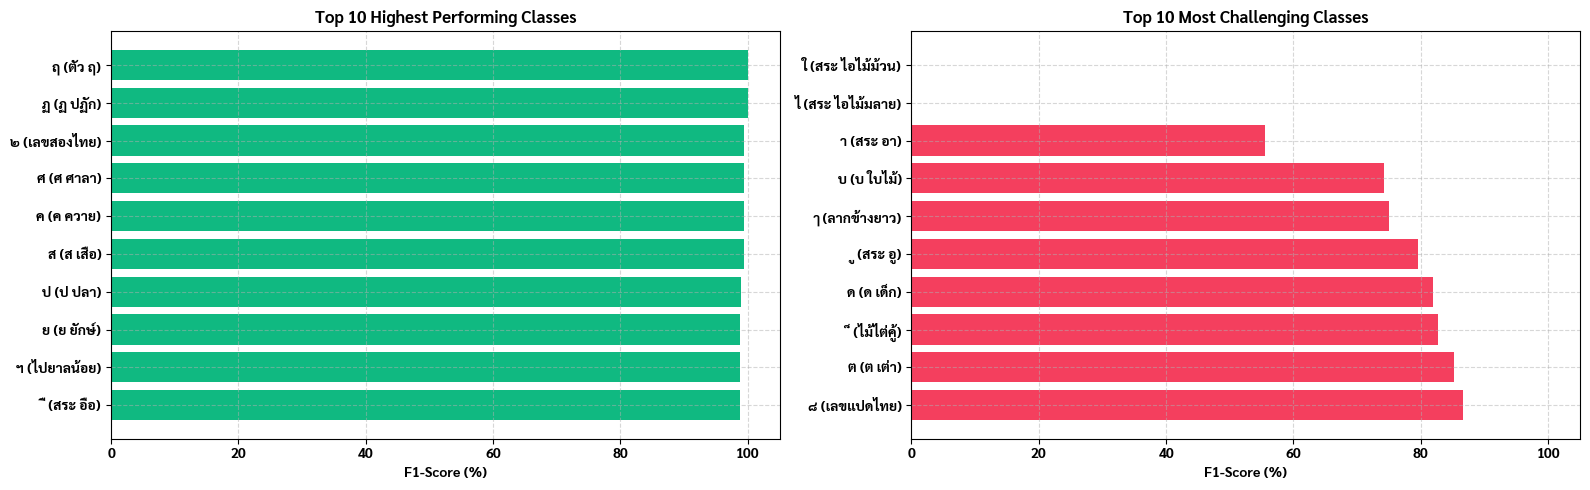

In [69]:
report_dict = classification_report(all_targets, all_preds, output_dict=True, zero_division=0)

class_metrics = []
for idx in range(num_classes):
    c_num = idx_to_class[idx]
    char_str = tis620_to_char(c_num)
    meta = THAI_CHAR_METADATA.get(c_num, {'name_th': f'รหัส {c_num}', 'name_en': f'Class {c_num}', 'type': 'General', 'meaning': '-'})
    str_idx = str(idx)
    
    if str_idx in report_dict:
        prec = report_dict[str_idx]['precision'] * 100.0
        rec = report_dict[str_idx]['recall'] * 100.0
        f1 = report_dict[str_idx]['f1-score'] * 100.0
        support = int(report_dict[str_idx]['support'])
    else:
        prec, rec, f1, support = 0.0, 0.0, 0.0, 0
        
    class_metrics.append({
        'Class Idx': idx,
        'TIS-620': c_num,
        'Character': char_str,
        'Thai Name': meta['name_th'],
        'English Name': meta['name_en'],
        'Linguistic Type': meta['type'],
        'Support': support,
        'Precision (%)': round(prec, 2),
        'Recall (%)': round(rec, 2),
        'F1-Score (%)': round(f1, 2),
    })

class_df = pd.DataFrame(class_metrics)

# Display Top 10 Best and Bottom 10 Hardest Classes
top10_best = class_df.sort_values(by=['F1-Score (%)', 'Support'], ascending=[False, False]).head(10)
bottom10_hardest = class_df.sort_values(by=['F1-Score (%)', 'Support'], ascending=[True, True]).head(10)

print("🌟 TOP 10 HIGHEST PERFORMING CHARACTERS:")
display(top10_best[['Character', 'TIS-620', 'Thai Name', 'Support', 'Precision (%)', 'Recall (%)', 'F1-Score (%)']])

print("⚠️ TOP 10 HARDEST / LOWEST PERFORMING CHARACTERS:")
display(bottom10_hardest[['Character', 'TIS-620', 'Thai Name', 'Support', 'Precision (%)', 'Recall (%)', 'F1-Score (%)']])

# Visual Comparison Bar Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ax1.barh([f"{r['Character']} ({r['Thai Name']})" for _, r in top10_best.iloc[::-1].iterrows()], top10_best['F1-Score (%)'].iloc[::-1], color='#10b981')
ax1.set_xlim(0, 105)
ax1.set_xlabel('F1-Score (%)', fontweight='bold')
ax1.set_title('Top 10 Highest Performing Classes', fontsize=12, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)

ax2.barh([f"{r['Character']} ({r['Thai Name']})" for _, r in bottom10_hardest.iloc[::-1].iterrows()], bottom10_hardest['F1-Score (%)'].iloc[::-1], color='#f43f5e')
ax2.set_xlim(0, 105)
ax2.set_xlabel('F1-Score (%)', fontweight='bold')
ax2.set_title('Top 10 Most Challenging Classes', fontsize=12, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


## 6. Full $72\times 72$ Confusion Matrix Visualizations
Inspect the comprehensive classification confusion matrix across all 72 classes (Raw Counts & Normalized Recall).

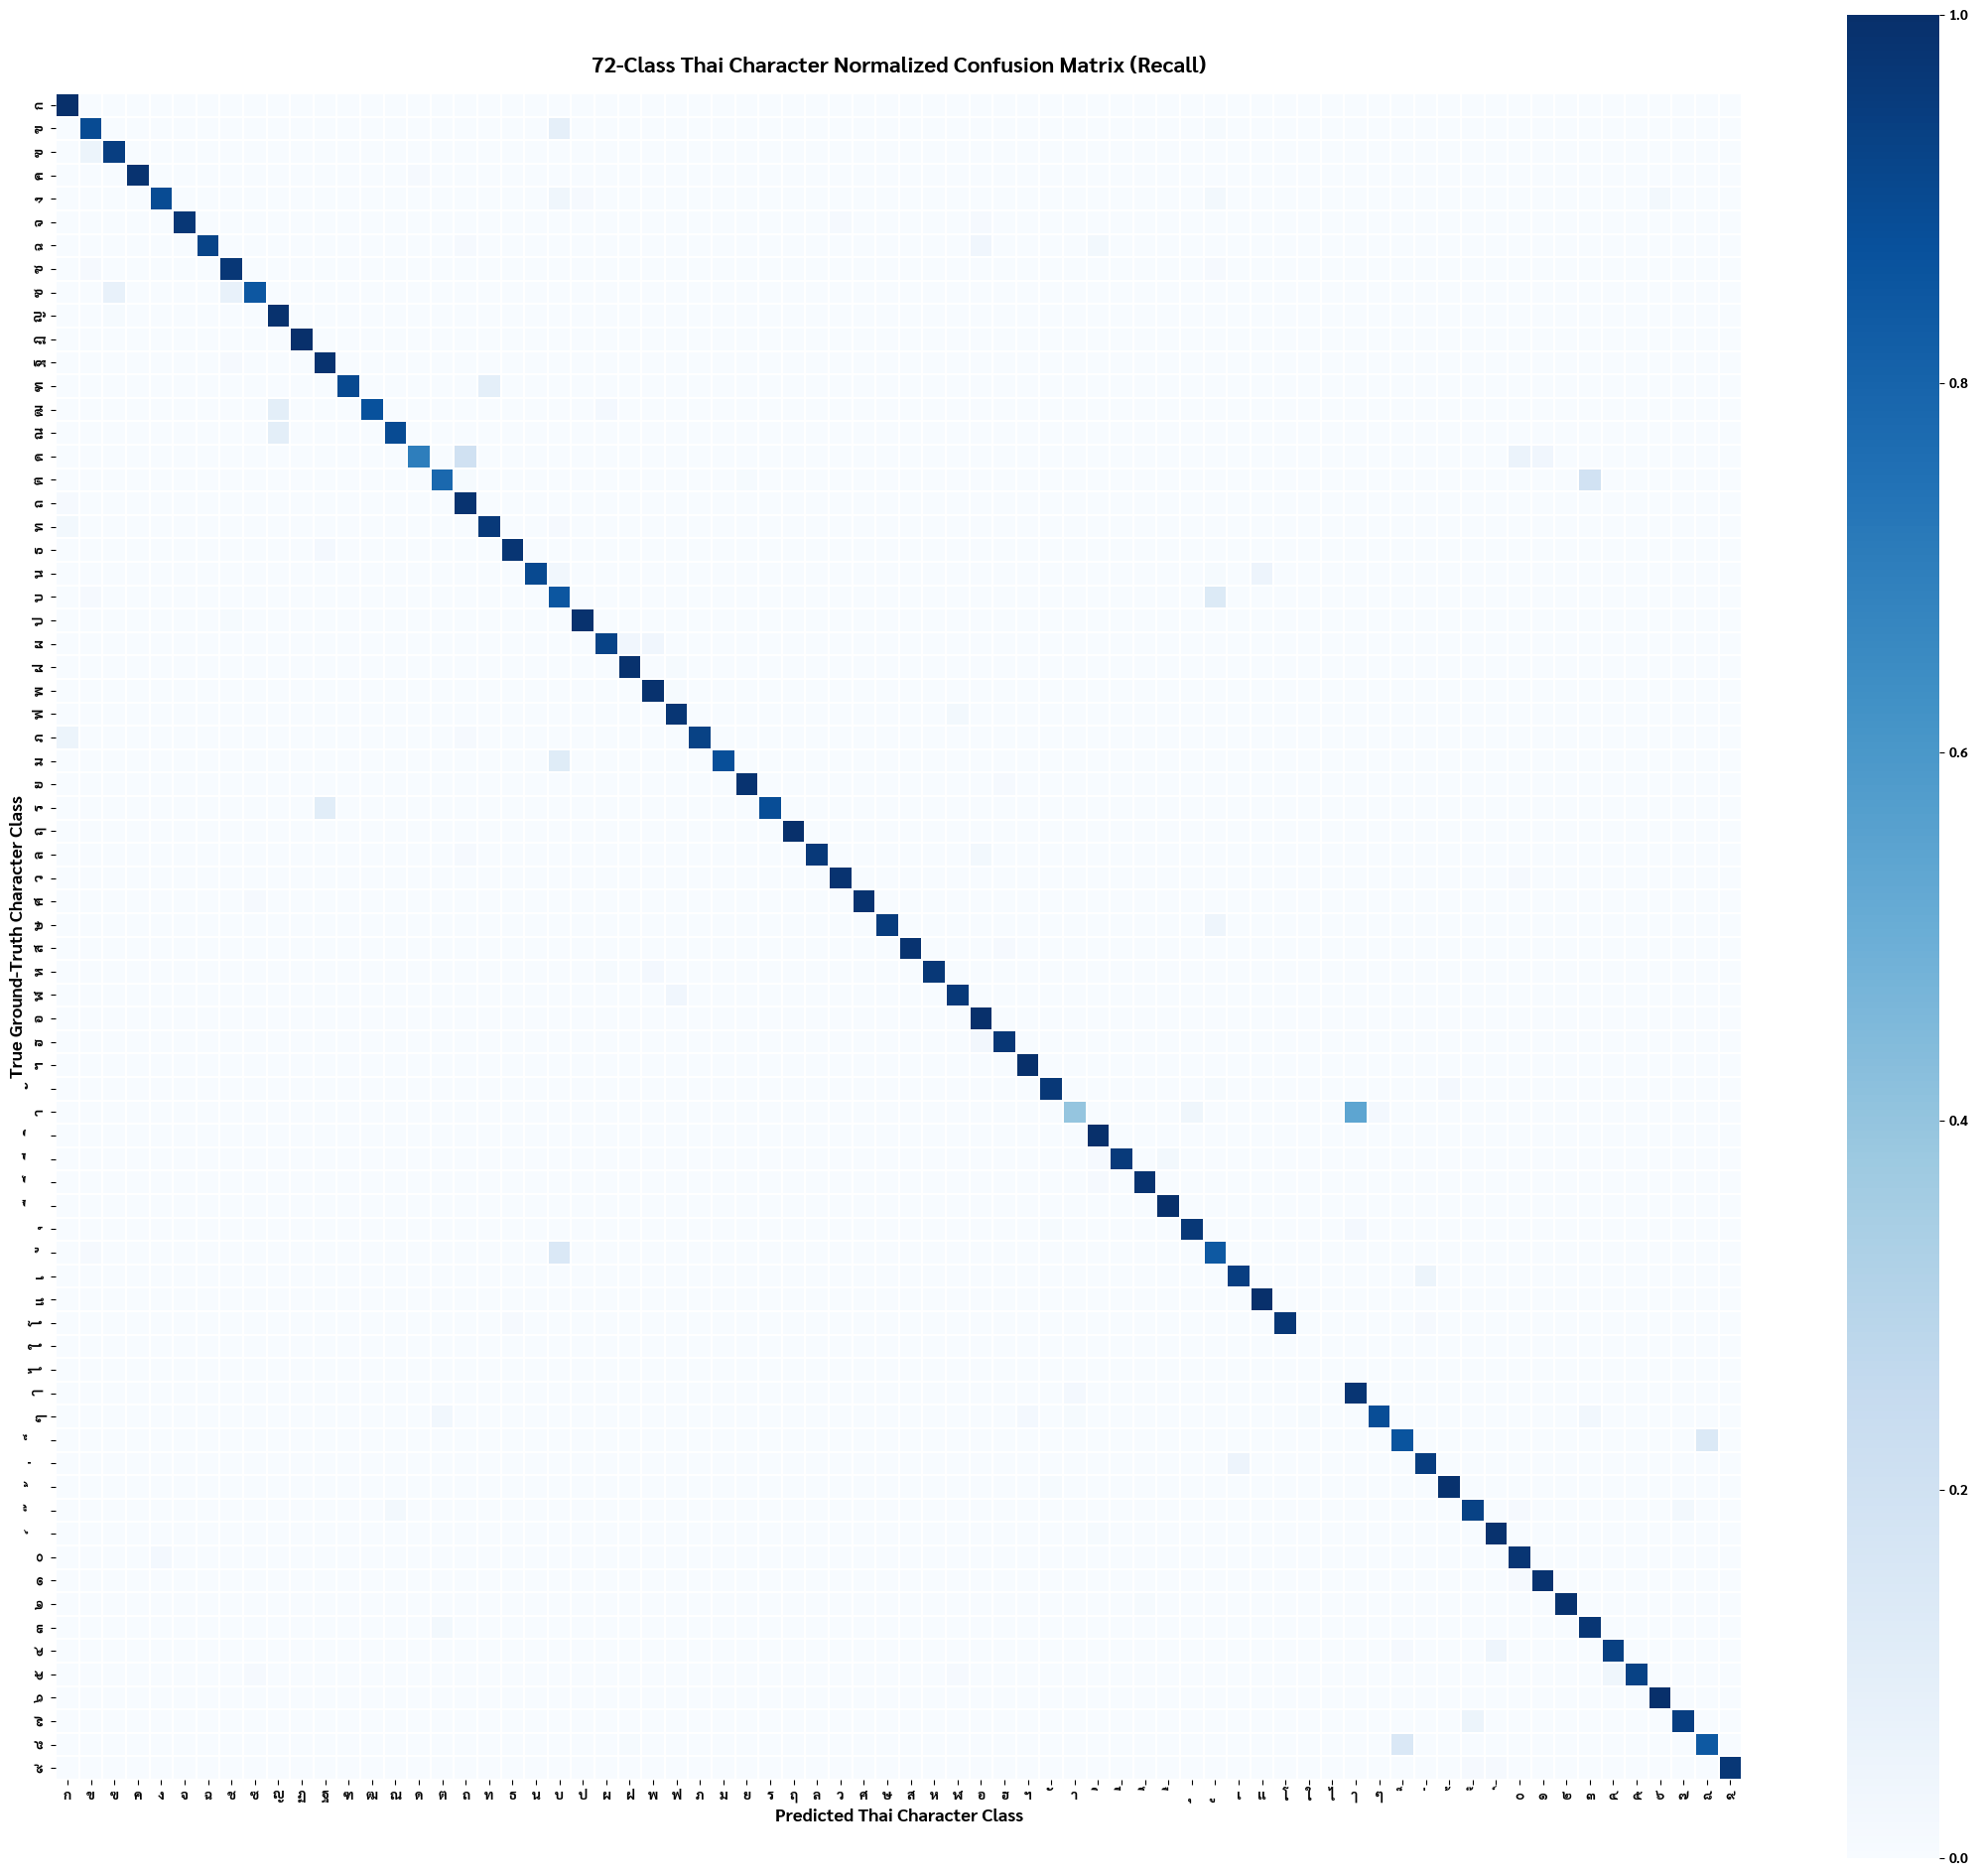

In [70]:
cm_raw = confusion_matrix(all_targets, all_preds, labels=list(range(num_classes)))
cm_norm = cm_raw.astype('float') / np.maximum(1, cm_raw.sum(axis=1)[:, np.newaxis])
char_labels = [tis620_to_char(idx_to_class[i]) for i in range(num_classes)]

# 1. Normalized Recall Confusion Matrix
plt.figure(figsize=(22, 19))
sns.heatmap(
    cm_norm,
    cmap='Blues',
    xticklabels=char_labels,
    yticklabels=char_labels,
    cbar=True,
    square=True,
    linewidths=0.2,
    vmin=0.0,
    vmax=1.0,
)
plt.title('72-Class Thai Character Normalized Confusion Matrix (Recall)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Predicted Thai Character Class', fontsize=13, fontweight='bold')
plt.ylabel('True Ground-Truth Character Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 7. In-Depth Error Auditing & Linguistic Confusion Diagnostics
Analyze the **Top-15 Most Frequently Confused Character Pairs** to uncover typographical similarities (e.g. head loop orientation, tail length, tooth count).

In [71]:
cm_errors = cm_raw.copy()
np.fill_diagonal(cm_errors, 0)
confused_indices = np.unravel_index(np.argsort(cm_errors.ravel())[::-1], cm_errors.shape)

TYPOGRAPHICAL_RATIONALES = {
    ('ข', 'ฃ'): 'Subtle serrated head notch on ฃ vs smooth head loop on ข',
    ('ฃ', 'ข'): 'Subtle serrated head notch on ฃ vs smooth head loop on ข',
    ('ค', 'ฅ'): 'Serrated top indent on ฅ vs smooth arched roof on ค',
    ('ฅ', 'ค'): 'Serrated top indent on ฅ vs smooth arched roof on ค',
    ('ช', 'ซ'): 'Serrated notch on upper stroke of ซ vs smooth arch of ช',
    ('ซ', 'ช'): 'Serrated notch on upper stroke of ซ vs smooth arch of ช',
    ('ด', 'ต'): 'Top-indent roof on ต vs smooth rounded roof on ด',
    ('ต', 'ด'): 'Top-indent roof on ต vs smooth rounded roof on ด',
    ('ผ', 'ฝ'): 'Ascender tail length (short on ผ vs tall on ฝ)',
    ('ฝ', 'ผ'): 'Ascender tail length (tall on ฝ vs short on ผ)',
    ('พ', 'ฟ'): 'Ascender tail length (short on พ vs tall on ฟ)',
    ('ฟ', 'พ'): 'Ascender tail length (tall on ฟ vs short on พ)',
    ('ภ', 'ถ'): 'Head loop orientation (outer loop on ภ vs inner loop on ถ)',
    ('ถ', 'ภ'): 'Head loop orientation (inner loop on ถ vs outer loop on ภ)',
    ('บ', 'ป'): 'Ascender tail length (short on บ vs tall on ป)',
    ('ป', 'บ'): 'Ascender tail length (tall on ป vs short on บ)',
    ('ฎ', 'ฏ'): 'Single lower curl on ฎ vs double zigzag serration on ฏ',
    ('ฏ', 'ฎ'): 'Double zigzag serration on ฏ vs single lower curl on ฎ',
    ('ญ', 'ณ'): 'Pedestal foot presence on ญ vs right-side loop structure on ณ',
    ('ณ', 'ญ'): 'Right-side loop structure on ณ vs pedestal foot on ญ',
}

confused_records = []
for true_idx, pred_idx in zip(confused_indices[0][:15], confused_indices[1][:15]):
    count = cm_errors[true_idx, pred_idx]
    if count == 0:
        continue
    true_tis = idx_to_class[true_idx]
    pred_tis = idx_to_class[pred_idx]
    true_char = tis620_to_char(true_tis)
    pred_char = tis620_to_char(pred_tis)
    true_support = int(cm_raw[true_idx].sum())
    error_pct = (count / max(1, true_support)) * 100.0
    rationale = TYPOGRAPHICAL_RATIONALES.get((true_char, pred_char), 'High visual stroke similarity / scanner bleed blur')
    
    confused_records.append({
        'True Character': true_char,
        'True Name': THAI_CHAR_METADATA.get(true_tis, {}).get('name_th', str(true_tis)),
        'Predicted Character': pred_char,
        'Predicted Name': THAI_CHAR_METADATA.get(pred_tis, {}).get('name_th', str(pred_tis)),
        'Misclassified Count': count,
        'Error Rate (% of True)': round(error_pct, 2),
        'Typographical Similarity Diagnostic': rationale,
    })

conf_df = pd.DataFrame(confused_records)
print("🔍 TOP 15 MOST CONFUSED CHARACTER PAIRS:")
display(conf_df)


🔍 TOP 15 MOST CONFUSED CHARACTER PAIRS:


,True Character,True Name,Predicted Character,Predicted Name,Misclassified Count,Error Rate (% of True),Typographical Similarity Diagnostic
0,า,สระ อา,ๅ,ลากข้างยาว,52,54.17,High visual stroke similarity / scanner bleed ...
1,ด,ด เด็ก,ถ,ถ ถุง,17,20.24,High visual stroke similarity / scanner bleed ...
2,ต,ต เต่า,๓,เลขสามไทย,17,19.32,High visual stroke similarity / scanner bleed ...
3,๘,เลขแปดไทย,็,ไม้ไต่คู้,13,14.77,High visual stroke similarity / scanner bleed ...
4,ู,สระ อู,บ,บ ใบไม้,11,14.47,High visual stroke similarity / scanner bleed ...
5,บ,บ ใบไม้,ู,สระ อู,11,13.58,High visual stroke similarity / scanner bleed ...
6,ม,ม ม้า,บ,บ ใบไม้,10,12.05,High visual stroke similarity / scanner bleed ...
7,ร,ร เรือ,ฐ,ฐ ฐาน,9,11.11,High visual stroke similarity / scanner bleed ...
8,็,ไม้ไต่คู้,๘,เลขแปดไทย,9,14.06,High visual stroke similarity / scanner bleed ...
9,ฒ,ฒ ผู้เฒ่า,ญ,ญ หญิง,9,10.47,High visual stroke similarity / scanner bleed ...


### Visual Error Gallery: Sample Misclassified Images
Inspect actual test images that were misclassified by the model along with their ground-truth and predicted labels.

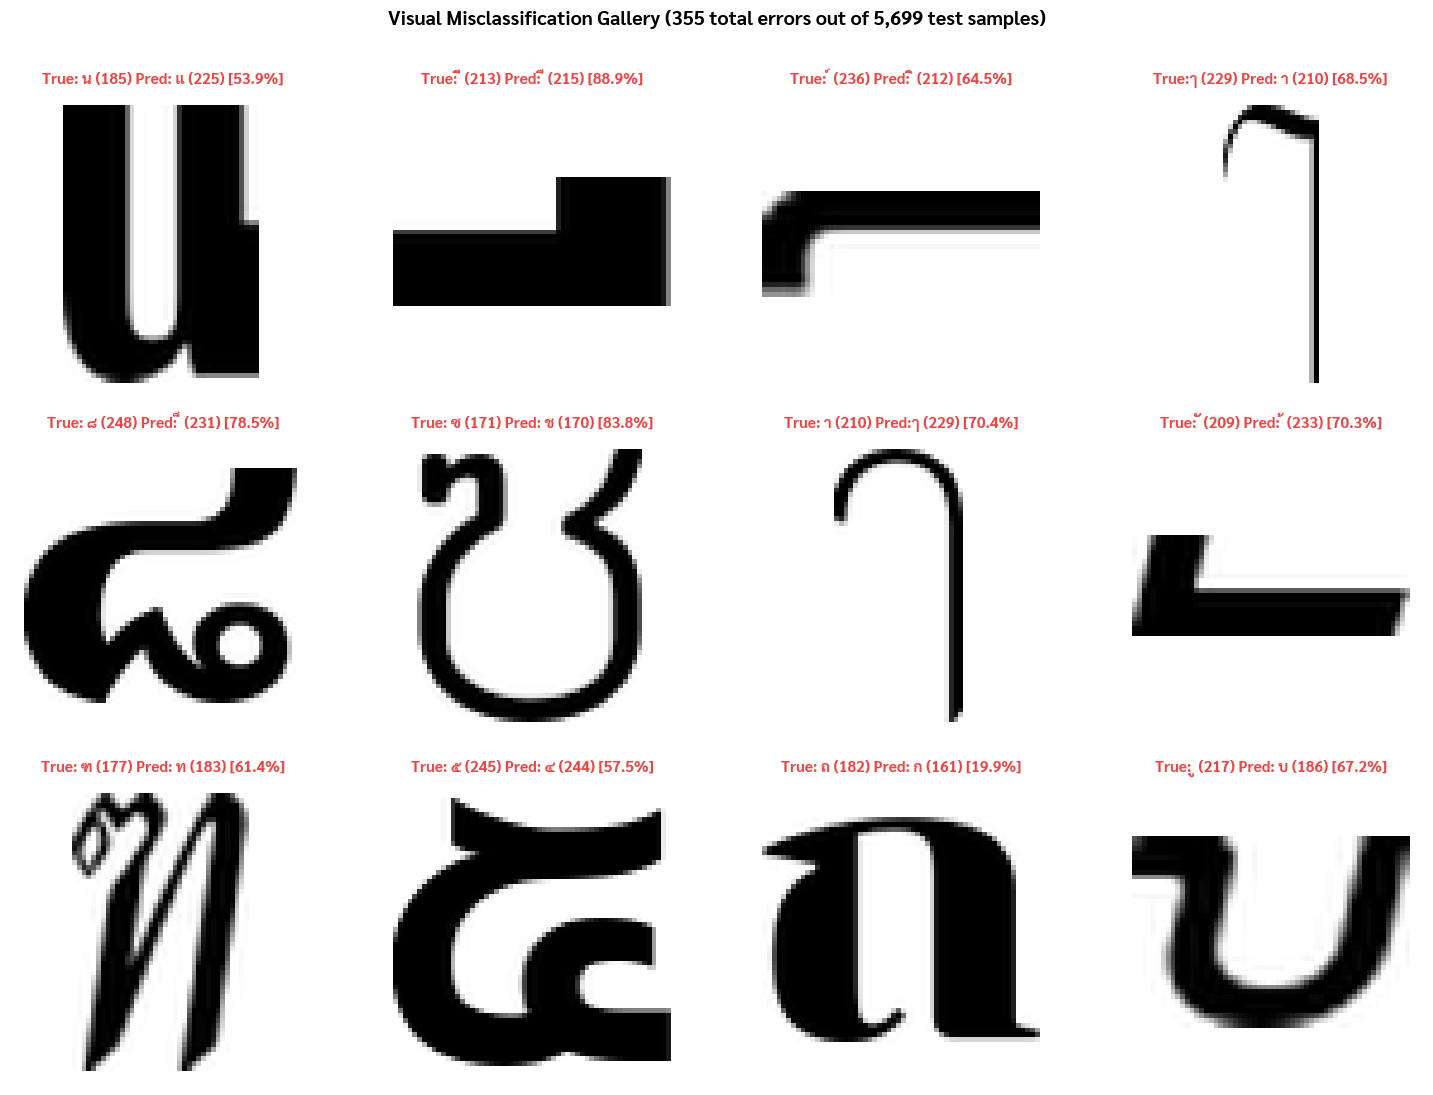

In [72]:
# Locate misclassified sample indices
mis_indices = np.where(all_preds != all_targets)[0]

if len(mis_indices) > 0:
    sample_count = min(12, len(mis_indices))
    selected_mis = np.random.choice(mis_indices, size=sample_count, replace=False)
    
    cols = 4
    rows = math.ceil(sample_count / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 3.6))
    axes = axes.flatten() if isinstance(axes, np.ndarray) else [axes]
    
    for i, idx in enumerate(selected_mis):
        row_data = test_df.iloc[idx]
        true_cls = all_targets[idx]
        pred_cls = all_preds[idx]
        true_ch = tis620_to_char(idx_to_class[true_cls])
        pred_ch = tis620_to_char(idx_to_class[pred_cls])
        conf = all_probs[idx, pred_cls] * 100.0
        
        img = Image.open(row_data['filepath']).convert('RGB')
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f"True: {true_ch} ({row_data['class_number']}) Pred: {pred_ch} ({idx_to_class[pred_cls]}) [{conf:.1f}%]", fontsize=11, color='#ef4444', fontweight='bold')
        axes[i].axis('off')
        
    for j in range(sample_count, len(axes)):
        axes[j].axis('off')
        
    plt.suptitle(f'Visual Misclassification Gallery ({len(mis_indices):,} total errors out of {len(test_df):,} test samples)', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print('🎉 Perfect classification! 0 errors detected in the test set.')


## 8. Single-Sample Interactive Inference & Top-5 Confidence
Test single-sample predictions with multi-stage visual preprocessing breakdown (Raw Image -> Inverted -> Bounding Box Crop -> Letterbox Padded Tensor).

🔮 SINGLE SAMPLE INFERENCE RESULT
🖼️  Sample File:      pho_samphao_Pattaya-Regular.png (C:\workspace\vscode\kmitl\3-1\dlmed\ThaiCharacterDataset\dataset-pai-cropped\192\pho_samphao_Pattaya-Regular.png)
🎯 Ground-Truth:     ภ (Class 192)
⭐ Top Prediction:   ภ - ภ สำเภา (Pho Samphao)
📊 Confidence:       77.2%
🏷️  Linguistic Type:  Consonant (Low)
📖 Meaning:          Sailboat


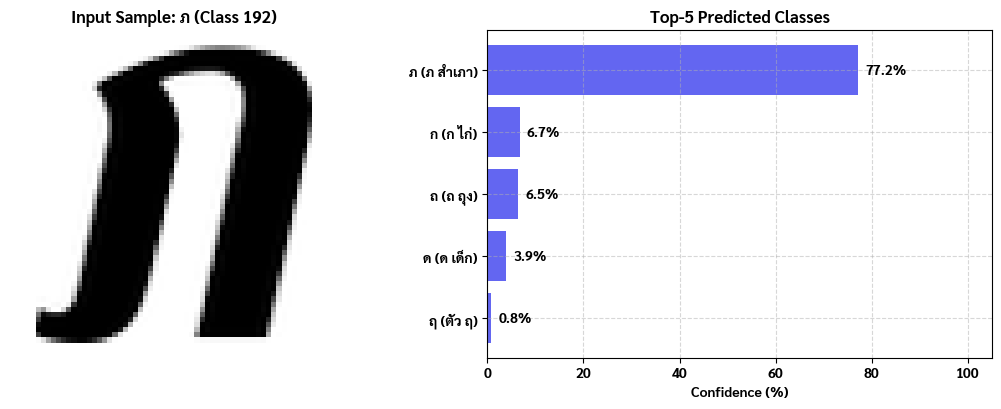

In [73]:
# Initialize inference engine with active model
engine = ThaiCharacterInferenceEngine(dataset_dir=DATASET_DIR, device=device)
engine.load_model('active_model', ckpt_path)

# Pick random sample from test set
sample_row = test_df.sample(1, random_state=random.randint(0, 100000)).iloc[0]
sample_img = Image.open(sample_row['filepath'])

pred_res = engine.predict(
    image_input=sample_img,
    model_name='active_model',
    top_k=5,
    pad_ratio=PAD_RATIO,
    use_focal_cleaner=USE_FOCAL_CLEANER,
    autocrop=True,
)

top1_p = pred_res['top_prediction']
print("=" * 65)
print("🔮 SINGLE SAMPLE INFERENCE RESULT")
print("=" * 65)
print(f"🖼️  Sample File:      {sample_row['filename']} ({sample_row['filepath']})")
print(f"🎯 Ground-Truth:     {sample_row['character']} (Class {sample_row['class_number']})")
print(f"⭐ Top Prediction:   {top1_p['character']} - {top1_p['name_th']} ({top1_p['name_en']})")
print(f"📊 Confidence:       {top1_p['confidence_pct']}%")
print(f"🏷️  Linguistic Type:  {top1_p['type']}")
print(f"📖 Meaning:          {top1_p['meaning']}")
print("=" * 65)

# Visualizing Input and Top-5 Predictions
fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(11, 4.2))

ax_img.imshow(sample_img, cmap='gray')
ax_img.set_title(f"Input Sample: {sample_row['character']} (Class {sample_row['class_number']})", fontsize=12, fontweight='bold')
ax_img.axis('off')

top_chars = [f"{p['character']} ({p['name_th']})" for p in pred_res['predictions'][::-1]]
top_confs = [p['confidence_pct'] for p in pred_res['predictions'][::-1]]

bars = ax_bar.barh(top_chars, top_confs, color='#6366f1')
ax_bar.set_xlim(0, 105)
ax_bar.set_xlabel('Confidence (%)', fontweight='bold')
ax_bar.set_title('Top-5 Predicted Classes', fontsize=12, fontweight='bold')
ax_bar.grid(True, linestyle='--', alpha=0.5)

for bar in bars:
    width = bar.get_width()
    ax_bar.text(width + 1.5, bar.get_y() + bar.get_height() / 2, f"{width:.1f}%", va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


## 9. Multi-Checkpoint Comparative Benchmark Leaderboard
Automatically evaluates all discovered model checkpoints in the repository on the identical test split to generate a comparative performance leaderboard.

🔬 Evaluating Repository Checkpoints on Identical Test Split...
  • Evaluating Solution 3 (ResNet-18 ver2) from best_model.pt...
  • Evaluating Solution 3 (CustomGlyphCNN ver1) from best_model.pt...
🏆 COMPARATIVE MODEL BENCHMARK LEADERBOARD


,Model Name,Architecture,Resolution,Top-1 Acc (%),Top-3 Acc (%),Macro-F1 (%),Weighted-F1 (%),Throughput (s/s),Latency (ms)
0,Solution 3 (ResNet-18 ver2),resnet18,64x64,93.77,98.84,92.50,93.73,1462.9,0.68
1,Solution 3 (CustomGlyphCNN ver1),custom_cnn,32x32,4.97,18.95,3.78,3.91,1755.8,0.57


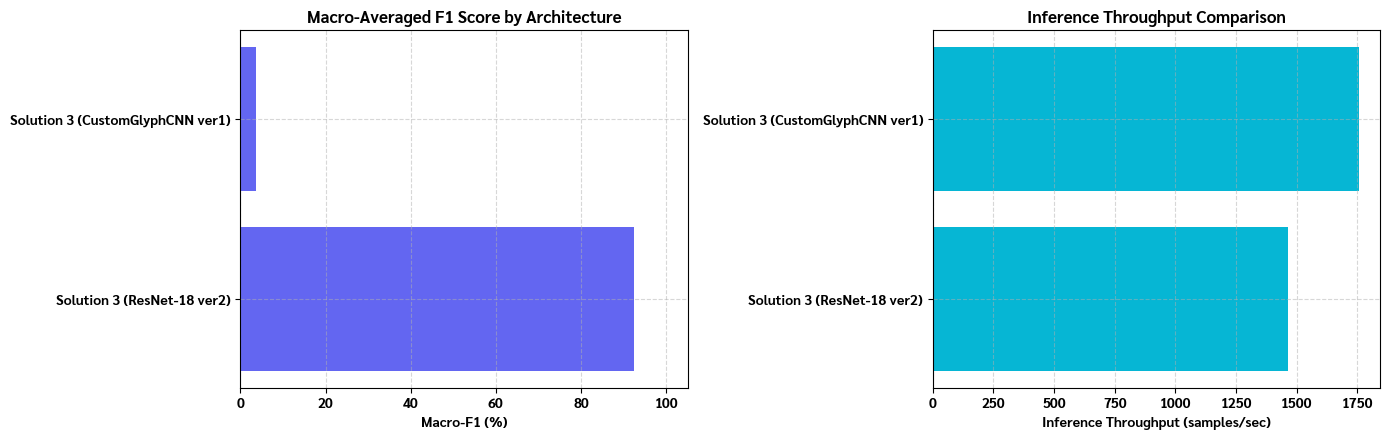

💾 Exported benchmark report to c:\workspace\vscode\kmitl\3-1\dlmed\DL-in-Medical-Image-Project-1\Solution 3 (Pai + Pooh)\ver2\benchmarks\standalone_evaluation_leaderboard.json


In [74]:
import json

benchmark_candidates = [
    ('Solution 3 (ResNet-18 ver2)', VER2_DIR / 'checkpoints' / 'resnet18' / 'best_model.pt'),
    ('Solution 3 (CustomGlyphCNN ver2)', VER2_DIR / 'checkpoints' / 'custom_cnn' / 'best_model.pt'),
    ('Solution 3 (CustomGlyphCNN ver1)', VER2_DIR / '..' / 'ver1' / 'checkpoints' / 'custom_cnn' / 'best_model.pt'),
    ('Solution 3 (MobileNetV3 ver2)', VER2_DIR / 'checkpoints' / 'mobilenet_v3' / 'best_model.pt'),
]

leaderboard_records = []
benchmark_engine = ThaiCharacterInferenceEngine(dataset_dir=DATASET_DIR, device=device)

print("🔬 Evaluating Repository Checkpoints on Identical Test Split...")
for name, p_path in benchmark_candidates:
    if p_path.exists():
        print(f"  • Evaluating {name} from {p_path.name}...")
        try:
            benchmark_engine.load_model(name, p_path)
            res = benchmark_engine.evaluate_loader(test_loader, model_name=name)
            leaderboard_records.append({
                'Model Name': name,
                'Architecture': res['model_type'],
                'Resolution': res['resolution'],
                'Top-1 Acc (%)': res['top1_accuracy'],
                'Top-3 Acc (%)': res['top3_accuracy'],
                'Macro-F1 (%)': res['macro_f1'],
                'Weighted-F1 (%)': res['weighted_f1'],
                'Throughput (s/s)': res['throughput_samples_per_sec'],
                'Latency (ms)': round(1000.0 / max(0.1, res['throughput_samples_per_sec']), 2),
            })
        except Exception as e:
            print(f"    ❌ Error evaluating {name}: {e}")

leaderboard_df = pd.DataFrame(leaderboard_records)
print(" " + "=" * 85)
print("🏆 COMPARATIVE MODEL BENCHMARK LEADERBOARD")
print("=" * 85)
display(leaderboard_df)

# Visual Leaderboard Comparison
if len(leaderboard_df) > 1:
    fig, (ax_f1, ax_lat) = plt.subplots(1, 2, figsize=(14, 4.5))
    
    ax_f1.barh(leaderboard_df['Model Name'], leaderboard_df['Macro-F1 (%)'], color='#6366f1')
    ax_f1.set_xlim(0, 105)
    ax_f1.set_xlabel('Macro-F1 (%)', fontweight='bold')
    ax_f1.set_title('Macro-Averaged F1 Score by Architecture', fontsize=12, fontweight='bold')
    ax_f1.grid(True, linestyle='--', alpha=0.5)
    
    ax_lat.barh(leaderboard_df['Model Name'], leaderboard_df['Throughput (s/s)'], color='#06b6d4')
    ax_lat.set_xlabel('Inference Throughput (samples/sec)', fontweight='bold')
    ax_lat.set_title('Inference Throughput Comparison', fontsize=12, fontweight='bold')
    ax_lat.grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

# Export JSON Benchmark Summary
benchmarks_dir = VER2_DIR / 'benchmarks'
benchmarks_dir.mkdir(parents=True, exist_ok=True)
with open(benchmarks_dir / 'standalone_evaluation_leaderboard.json', 'w', encoding='utf-8') as f:
    json.dump(leaderboard_records, f, indent=2)
print(f"💾 Exported benchmark report to {benchmarks_dir / 'standalone_evaluation_leaderboard.json'}")
